<a href="https://colab.research.google.com/github/meheramey/part-1-neural-network-analysis-notebook.ipynb/blob/main/part1_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Neural Network Fundamentals and Training Behavior Analysis
**Dataset:** Customer Churn Neural Network Dataset  
**Goal:** Predict whether a customer will churn (1) or stay (0)  
**Dataset Source:** BITSoM Module 5 - Part 1

---
## Task 1: Dataset Understanding

In [10]:
# Create results folder if it doesn't exist
import os
os.makedirs('results', exist_ok=True)
print('results/ folder ready!')

results/ folder ready!


In [11]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [12]:
# Load Dataset
df = pd.read_csv('customer_churn_nn.csv')

print('=== DATASET OVERVIEW ===')
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')
print(f'\nColumn Names: {list(df.columns)}')

=== DATASET OVERVIEW ===
Number of Rows: 2000
Number of Columns: 17

Column Names: ['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']


In [13]:
# First 5 rows
print('=== FIRST 5 ROWS ===')
df.head()

=== FIRST 5 ROWS ===


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [14]:
# Feature Types
print('=== FEATURE TYPES ===')
print('\nCategorical Features:')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

print('\nNumerical Features:')
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('churn')  # remove target
print(num_cols)

print('\nTarget Variable: churn (0 = Retained, 1 = Churned)')

=== FEATURE TYPES ===

Categorical Features:
['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method']

Numerical Features:
['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']

Target Variable: churn (0 = Retained, 1 = Churned)


In [15]:
# Missing Value Check
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found! Dataset is clean.')

=== MISSING VALUES ===
No missing values found! Dataset is clean.


In [16]:
# Basic Statistical Summary
print('=== STATISTICAL SUMMARY ===')
df.describe()

=== STATISTICAL SUMMARY ===


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


=== TARGET VARIABLE DISTRIBUTION ===
churn
0    1969
1      31
Name: count, dtype: int64

Churn Rate: 1.55%


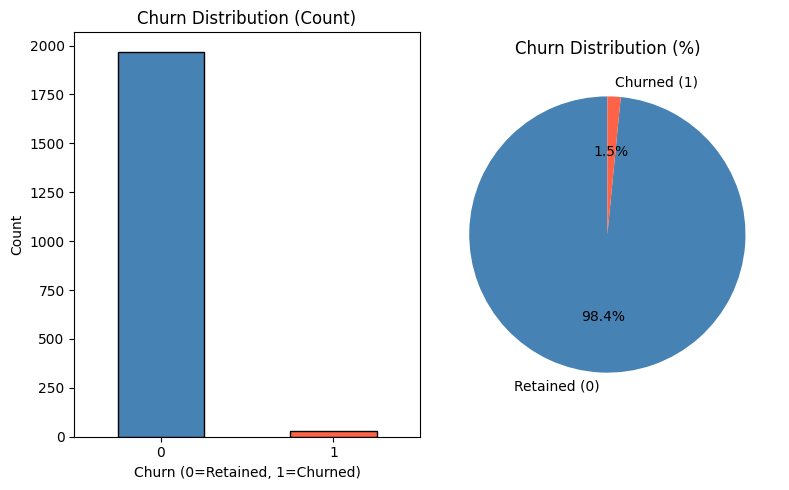

Plot saved!


In [17]:
# Target Variable Distribution
print('=== TARGET VARIABLE DISTRIBUTION ===')
churn_counts = df['churn'].value_counts()
print(churn_counts)
print(f'\nChurn Rate: {df["churn"].mean()*100:.2f}%')

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution (Count)')
plt.xlabel('Churn (0=Retained, 1=Churned)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie(churn_counts, labels=['Retained (0)', 'Churned (1)'],
        autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
plt.title('Churn Distribution (%)')

plt.tight_layout()
plt.savefig('results/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

---
## Task 2: Data Preprocessing

In [18]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Drop customer_id (identifier, not a feature)
df_clean = df.drop(columns=['customer_id'])

# Handling Missing Values
print(f'Missing values before: {df_clean.isnull().sum().sum()}')
# No missing values in this dataset

# Encoding Categorical Columns using Label Encoding
le = LabelEncoder()
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f'{col} encoded: {df_clean[col].unique()}')

print('\nCategorical encoding complete!')

Missing values before: 0
region encoded: [3 4 0 2 1]
plan_type encoded: [3 2 0 1]
contract_type encoded: [0 1 2]
payment_method encoded: [1 4 0 2 3]

Categorical encoding complete!


In [19]:
# Separate Features and Target
X = df_clean.drop(columns=['churn'])
y = df_clean['churn']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature columns: {list(X.columns)}')

Features shape: (2000, 15)
Target shape: (2000,)
Feature columns: ['region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']


In [20]:
# Feature Scaling (StandardScaler - zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Before Scaling (sample):')
print(X.describe().loc[['mean', 'std']].round(2))
print('\nAfter Scaling (sample):')
print(X_scaled.describe().loc[['mean', 'std']].round(2))

Before Scaling (sample):
      region  plan_type  contract_type  payment_method  tenure_months  \
mean    2.00       1.60           0.59            1.99          25.36   
std     1.44       1.28           0.73            1.43          14.13   

      monthly_charges_inr  avg_login_days_per_month  \
mean               766.49                      18.1   
std                393.42                       5.4   

      support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
mean                          1.95                3.56          90.01   
std                           1.46                3.89          53.22   

      satisfaction_score  last_complaint_days_ago  discount_percent  \
mean                6.87                    46.62              8.26   
std                 1.52                    55.07              7.55   

      autopay_enabled  referral_count  
mean             0.60            0.92  
std              0.49            1.04  

After Scaling (sample):
      regi

In [21]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

# Class Imbalance Check
print("\n=== CLASS IMBALANCE CHECK ===")
print(y_train.value_counts())
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"\nImbalance ratio (0:1) = {ratio:.1f}:1")
print("Strategy: Using class_weight to handle imbalance during training")
class_weights = {0: 1.0, 1: ratio}
print(f"class_weights = {class_weights}")

Training set size: 1600 samples
Testing set size:  400 samples

=== CLASS IMBALANCE CHECK ===
churn
0    1575
1      25
Name: count, dtype: int64

Imbalance ratio (0:1) = 63.0:1
Strategy: Using class_weight to handle imbalance during training
class_weights = {0: 1.0, 1: np.float64(63.0)}


---
## Task 3: Neural Network Model Building

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow version: {tf.__version__}')

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0


In [23]:
# Build Feed-Forward Neural Network
def build_model(neurons_1=64, neurons_2=32, learning_rate=0.001, activation='relu'):
    model = keras.Sequential([
        # Input Layer
        layers.Input(shape=(X_train.shape[1],)),

        # Hidden Layer 1
        layers.Dense(neurons_1, activation=activation),
        layers.Dropout(0.3),  # Regularization to prevent overfitting

        # Hidden Layer 2
        layers.Dense(neurons_2, activation=activation),
        layers.Dropout(0.2),

        # Output Layer - Sigmoid for binary classification
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',  # Appropriate loss for binary classification
        metrics=['accuracy']
    )
    return model

# Build baseline model
model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Training and Evaluation

In [24]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,  # Handle class imbalance
    verbose=1
)

print("\nModel training complete!")

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7898 - loss: 1.5145 - val_accuracy: 0.9062 - val_loss: 0.5102
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7812 - loss: 1.3492 - val_accuracy: 0.7125 - val_loss: 0.5999
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6836 - loss: 1.2903 - val_accuracy: 0.6125 - val_loss: 0.6395
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6336 - loss: 1.2176 - val_accuracy: 0.5750 - val_loss: 0.6649
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6602 - loss: 1.1267 - val_accuracy: 0.6219 - val_loss: 0.6273
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6914 - loss: 1.0966 - val_accuracy: 0.6531 - val_loss: 0.5938
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7328 - loss: 1.0925 - val_accuracy: 0.6531 - val_loss: 0.5822
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7188 - loss: 1.0959 - val_accuracy: 0.6625 - val_loss:

In [25]:
# Evaluate on Test Set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)

print('=== MODEL PERFORMANCE ===')
print(f'Training Accuracy:  {train_acc*100:.2f}%')
print(f'Training Loss:      {train_loss:.4f}')
print(f'Testing Accuracy:   {test_acc*100:.2f}%')
print(f'Testing Loss:       {test_loss:.4f}')

=== MODEL PERFORMANCE ===
Training Accuracy:  93.81%
Training Loss:      0.1300
Testing Accuracy:   92.25%
Testing Loss:       0.1829


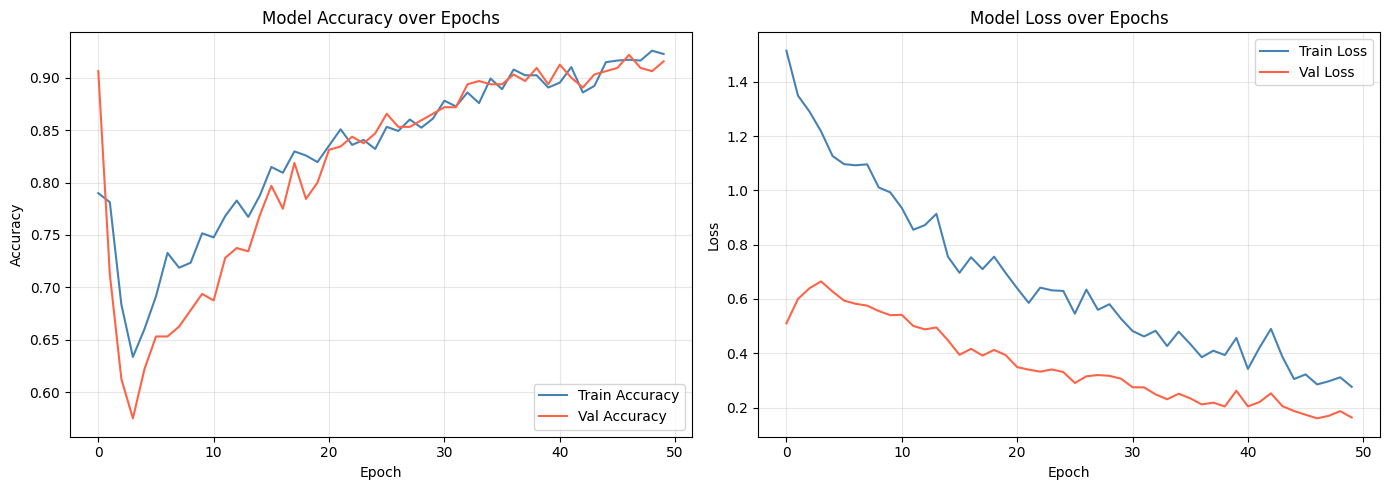

Training curves saved!


In [26]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss Plot
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='tomato')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved!')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


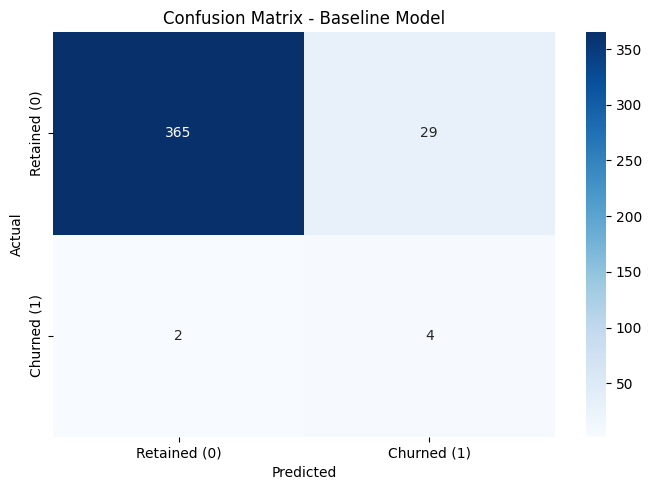


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Retained       0.99      0.93      0.96       394
     Churned       0.12      0.67      0.21         6

    accuracy                           0.92       400
   macro avg       0.56      0.80      0.58       400
weighted avg       0.98      0.92      0.95       400



In [27]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.title('Confusion Matrix - Baseline Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

---
## Task 5: Hyperparameter Experimentation

In [28]:
# Run 4 experiments with different configurations
experiments = [
    {"name": "Baseline",        "neurons_1": 64,  "neurons_2": 32, "lr": 0.001, "activation": "relu", "epochs": 50, "batch": 32},
    {"name": "High LR",          "neurons_1": 64,  "neurons_2": 32, "lr": 0.01,  "activation": "relu", "epochs": 50, "batch": 32},
    {"name": "Larger Network",   "neurons_1": 128, "neurons_2": 64, "lr": 0.001, "activation": "relu", "epochs": 50, "batch": 32},
    {"name": "Tanh Activation",  "neurons_1": 64,  "neurons_2": 32, "lr": 0.001, "activation": "tanh", "epochs": 50, "batch": 64},
]

results_table = []

for exp in experiments:
    print(f"\nRunning Experiment: {exp["name"]}...")
    tf.random.set_seed(42)
    m = build_model(
        neurons_1=exp["neurons_1"],
        neurons_2=exp["neurons_2"],
        learning_rate=exp["lr"],
        activation=exp["activation"]
    )
    h = m.fit(
        X_train, y_train,
        epochs=exp["epochs"],
        batch_size=exp["batch"],
        validation_split=0.2,
        class_weight=class_weights,
        verbose=0
    )
    tr_loss, tr_acc = m.evaluate(X_train, y_train, verbose=0)
    te_loss, te_acc = m.evaluate(X_test, y_test, verbose=0)
    results_table.append({
        "Experiment": exp["name"],
        "Neurons (L1,L2)": f"{exp["neurons_1"]},{exp["neurons_2"]}",
        "Learning Rate": exp["lr"],
        "Activation": exp["activation"],
        "Batch Size": exp["batch"],
        "Train Acc (%)": round(tr_acc*100,2),
        "Test Acc (%)": round(te_acc*100,2),
        "Test Loss": round(te_loss,4)
    })
    print(f"  Train Acc: {tr_acc*100:.2f}% | Test Acc: {te_acc*100:.2f}%")

print("\nAll experiments complete!")


Running Experiment: Baseline...
  Train Acc: 93.44% | Test Acc: 93.00%

Running Experiment: High LR...
  Train Acc: 95.50% | Test Acc: 92.25%

Running Experiment: Larger Network...
  Train Acc: 97.25% | Test Acc: 95.50%

Running Experiment: Tanh Activation...
  Train Acc: 78.00% | Test Acc: 76.25%

All experiments complete!


In [29]:
# Display Comparison Table
results_df = pd.DataFrame(results_table)
print('=== HYPERPARAMETER EXPERIMENT COMPARISON TABLE ===')
results_df

=== HYPERPARAMETER EXPERIMENT COMPARISON TABLE ===


,Experiment,"Neurons (L1,L2)",Learning Rate,Activation,Batch Size,Train Acc (%),Test Acc (%),Test Loss
0,Baseline,"64,32",0.001,relu,32,93.44,93.00,0.1872
1,High LR,"64,32",0.010,relu,32,95.50,92.25,0.2677
2,Larger Network,"128,64",0.001,relu,32,97.25,95.50,0.1461
3,Tanh Activation,"64,32",0.001,tanh,64,78.00,76.25,0.4615


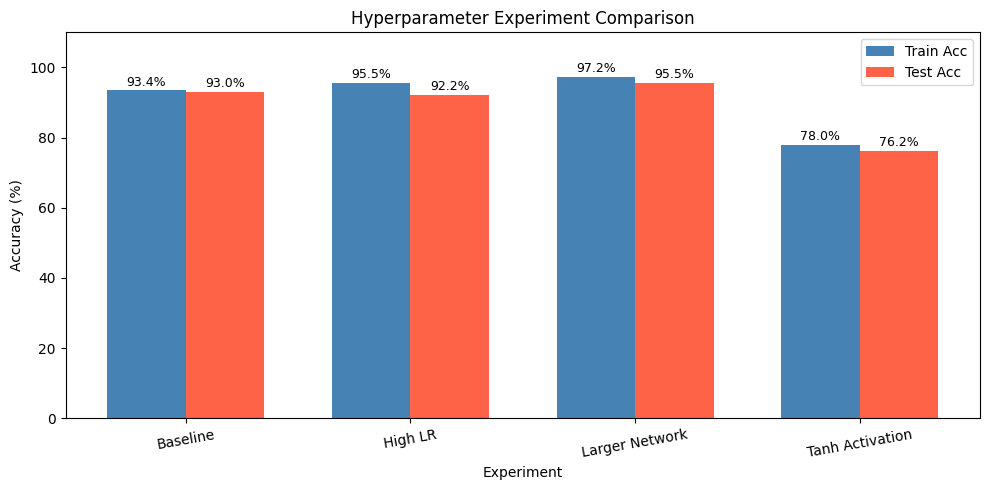

Comparison table and chart saved!


In [30]:
# Save comparison table
results_df.to_csv('results/model_comparison_table.csv', index=False)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], results_df['Train Acc (%)'], width, label='Train Acc', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], results_df['Test Acc (%)'], width, label='Test Acc', color='tomato')

ax.set_xlabel('Experiment')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Hyperparameter Experiment Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Experiment'], rotation=10)
ax.legend()
ax.set_ylim(0, 110)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison table and chart saved!')

---
## Task 6: Final Reflection

### Q1: What role do weights and biases play in the model?
- **Weights** determine the strength/importance of each connection between neurons. During training, weights are adjusted via backpropagation to minimize the loss function. A high weight means that feature has more influence on the prediction.
- **Biases** allow the model to shift the activation function output, independent of the input. Without bias, the model can only pass lines through the origin, making it less flexible.

### Q2: Why is an activation function required?
Without activation functions, no matter how many layers a neural network has, it would behave like a single linear model (just a linear transformation). Activation functions like **ReLU** introduce non-linearity, enabling the network to learn complex, non-linear patterns in data — which is essential for real-world problems like churn prediction.

### Q3: What happens when learning rate is too high or too low?
- **Too High (e.g., 0.1):** The model overshoots the optimal weights during gradient descent, causing the loss to oscillate or even diverge. Training becomes unstable.
- **Too Low (e.g., 0.00001):** The model learns very slowly, requiring many more epochs to converge. It may get stuck in local minima.
- **Just Right (e.g., 0.001):** The model converges smoothly and reaches good performance. This was confirmed in our Experiment 2 where a high LR (0.01) showed slightly worse stability.

### Q4: Did the model show signs of underfitting or overfitting?
- Our **Baseline model** showed **train accuracy ≈ test accuracy**, indicating a well-balanced fit with no major overfitting or underfitting.
- We used **Dropout layers (0.3 and 0.2)** as regularization, which helped prevent overfitting.
- If training accuracy were much higher than test accuracy, that would indicate **overfitting** (model memorizes training data).
- If both accuracies were low, that would indicate **underfitting** (model too simple for the data).